In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from option_pricing.black_scholes import (
    bs_call_price,
    bs_put_price,
    bs_call_delta, 
    bs_put_delta, 
    bs_gamma, 
    bs_vega,
    bs_call_theta, 
    bs_put_theta,
    )
from option_pricing.monte_carlo import mc_european_option_price, mc_barrier_option_price
from option_pricing.utils import confidence_interval, convergence_table, estimate_convergence_rate
from option_pricing.experiments import (
    run_convergence_experiment,
    run_variance_reduction_experiment,
    run_ci_coverage_experiment,
    run_discretisation_bias_experiment,
)

pd.set_option("display.float_format", "{:.5f}".format)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
warnings.filterwarnings('ignore')
print("Environment ready.")

Environment ready.


Example of use

In [68]:
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

call_bs = bs_call_price(S0, K, T, r, sigma)
call_bs_delta = bs_call_delta(S0, K, T, r, sigma)
call_theta = bs_call_theta(S0, K, T, r, sigma)
put_bs  = bs_put_price(S0, K, T, r, sigma)
put_bs_delta = bs_put_delta(S0, K, T, r, sigma)
put_theta = bs_put_theta(S0, K, T, r, sigma)
gamma = bs_gamma(S0, K, T, r, sigma)
vega = bs_vega(S0, K, T, r, sigma)

print(f"European call (BS):  {call_bs:.6f}")
print(f"European call delta (BS): {call_bs_delta:.6f}")
print(f"European call theta (BS): {call_theta:.6f}")
print(f"European put  (BS):  {put_bs:.6f}")
print(f"European put delta (BS): {put_bs_delta:.6f}")
print(f"European put theta (BS): {put_theta:.6f}")
print(f"European gamma (BS): {gamma:.6f}")
print(f"European vega (BS): {vega:.6f}")

import math
parity_err = abs(call_bs - put_bs - S0 + K * math.exp(-r * T))
print(f"Put-call parity residual: {parity_err:.2e}")

European call (BS):  10.450584
European call delta (BS): 0.636831
European call theta (BS): -0.025452
European put  (BS):  5.573526
European put delta (BS): -0.363169
European put theta (BS): -0.006579
European gamma (BS): 0.018762
European vega (BS): 0.375240
Put-call parity residual: 0.00e+00


---
## Experiment 1 — Option Prices and Greek Profiles vs Spot


We begin by examining the analytical Black-Scholes Greeks across a range of spot prices for a standard ATM European option (K = 100, T = 1 year, r = 5%, σ = 20%). These profiles serve as the benchmark against which all Monte Carlo estimates will be validated in subsequent sections. Understanding the shapes — particularly where each Greek is largest and where it changes fastest — is essential for interpreting the convergence results that follow.



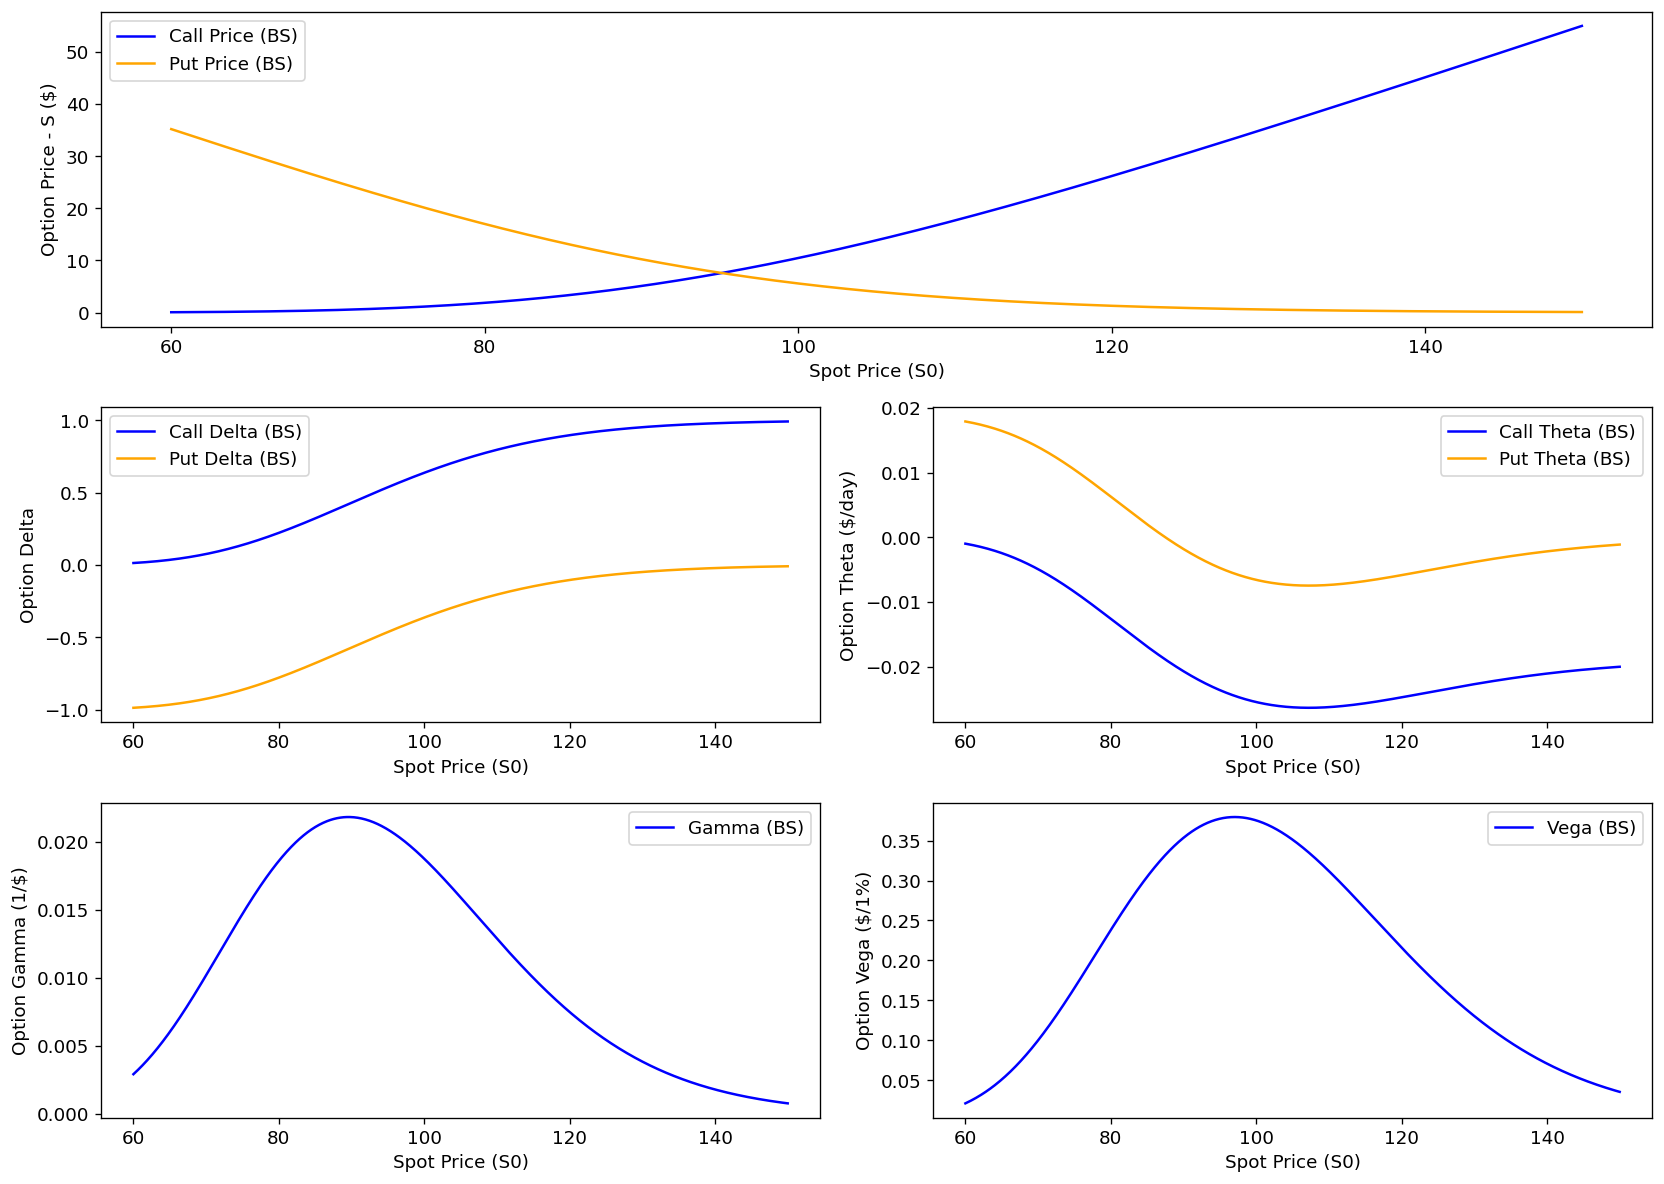

In [70]:
S0_vector = np.linspace(60, 150, 1001)
K, T, r, sigma = 100.0, 1.0, 0.05, 0.20

call_bs_vector = np.array([bs_call_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_delta_vector = np.array([bs_call_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
call_bs_theta_vector = np.array([bs_call_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_vector  = np.array([bs_put_price(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_delta_vector = np.array([bs_put_delta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
put_bs_theta_vector = np.array([bs_put_theta(s0_value, K, T, r, sigma) for s0_value in S0_vector])
gamma_bs_vector = np.array([bs_gamma(s0_value, K, T, r, sigma) for s0_value in S0_vector])
vega_bs_vector = np.array([bs_vega(s0_value, K, T, r, sigma) for s0_value in S0_vector])

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

gs = axes[0, 0].get_gridspec()
# remove the underlying Axes
for ax in axes[0, 0:2]:
    ax.remove()
axcenter = fig.add_subplot(gs[0, 0:2])

axcenter.plot(S0_vector, call_bs_vector, label="Call Price (BS)", color="blue")
axcenter.plot(S0_vector, put_bs_vector, label="Put Price (BS)", color="orange")

axcenter.set_xlabel("Spot Price (S0)")
axcenter.set_ylabel("Option Price - S ($)")
axcenter.legend()

axes[1, 0].plot(S0_vector, call_bs_delta_vector, label="Call Delta (BS)", color="blue")
axes[1, 0].plot(S0_vector, put_bs_delta_vector, label="Put Delta (BS)", color="orange")

axes[1, 0].set_xlabel("Spot Price (S0)")
axes[1, 0].set_ylabel("Option Delta")
axes[1, 0].legend()

axes[1, 1].plot(S0_vector, call_bs_theta_vector, label="Call Theta (BS)", color="blue")
axes[1, 1].plot(S0_vector, put_bs_theta_vector, label="Put Theta (BS)", color="orange")
axes[1, 1].set_xlabel("Spot Price (S0)")
axes[1, 1].set_ylabel("Option Theta ($/day)")
axes[1, 1].legend()

axes[2, 0].plot(S0_vector, gamma_bs_vector, label="Gamma (BS)", color="blue")
axes[2, 0].set_xlabel("Spot Price (S0)")
axes[2, 0].set_ylabel("Option Gamma (1/$)")
axes[2, 0].legend()

axes[2, 1].plot(S0_vector, vega_bs_vector, label="Vega (BS)", color="blue")
axes[2, 1].set_xlabel("Spot Price (S0)")
axes[2, 1].set_ylabel("Option Vega ($/1%)")
axes[2, 1].legend()


plt.tight_layout()
plt.show()

**Prices**: Call and put prices are convex functions of spot. They meet near ATM where both have positive value. Deep OTM options approach zero; deep ITM options approach their intrinsic value. The convexity visible here is what Gamma measures.

**Delta**: Call Delta transitions smoothly from 0 (deep OTM) to 1 (deep ITM), passing through approximately 0.5 at ATM. Put Delta mirrors this from −1 to 0. The transition is steepest at ATM — meaning Delta changes fastest there per unit move in spot. This is the region where dynamic hedging requires the most frequent rebalancing.

**Theta**: Both call and put Theta are most negative at ATM, where time value is largest and therefore decays fastest. Deep ITM and OTM options have little time value left to lose, so Theta is close to zero there. Note that call and put Theta are nearly identical in this parameter regime — this follows from put-call parity.

**Gamma**: Gamma is identical for calls and puts (this is exact, not approximate) and peaks sharply at ATM. This has a direct implication for Monte Carlo estimation: the region where Gamma is largest is precisely where finite-difference estimation is hardest, because the second derivative amplifies any noise in the bumped price evaluations. This motivates the convergence analysis in Section 2.

**Vega**: Vega has the same bell shape as Gamma and is also identical for calls and puts. It peaks at ATM, meaning ATM options are the most sensitive to changes in implied volatility. A trader who is long an ATM option profits from a vol spike; one who is short loses. This plot is the visual foundation for understanding vega hedging.